# Step 0: NLE Generation — Shared Foundation

**Purpose:** Generate one NLE per test instance (N=60) using both GPT-4o and DeepSeek-R1.

**Fixed pipeline:** XGBoost + SHAP (TreeExplainer) + zero-shot (see `0_1_from_first_to_second_paper.md` for justification)

**Output:** `results/nle/nle_cache_gpt.csv` and `results/nle/nle_cache_deepseek.csv` — 60 rows each (120 total), used by E1, E3, E4, E5. Load both with `utils.load_nle_cache()`.

**Why two generators:** Bias cancellation in the 2×2 generator×judge design. Averaging across all four combinations cancels LLM self-preference bias. This is NOT to compare generator quality (Paper 1 already did that).

**Note:** E2 (poisoning experiment) uses its own separately generated NLEs and is already complete.

---

**XGBoost model provenance:**
`Code/from_XAI_trustlab/serialized_models/XGB_model.joblib` is a byte-for-byte copy of the Paper 1 model (`XAITrustLab/first_paper/explanation_generation/serialized_models/XGB_model.joblib`) — confirmed via MD5 hash match. Verified performance on the 60-instance test set: **R²=0.686, MAE=20.55 kWh** (Paper 1 reports R²=0.69, MAE=20.55 kWh). Do NOT retrain.

## 0. Setup

In [1]:
import sys
import asyncio
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import pandas as pd
import numpy as np

import utils

# Per-generator caches live in results/nle/
CACHE_GPT = utils.NLE_DIR / 'nle_cache_gpt.csv'
CACHE_DS  = utils.NLE_DIR / 'nle_cache_deepseek.csv'
utils.NLE_DIR.mkdir(parents=True, exist_ok=True)

print(f'NLE dir  : {utils.NLE_DIR}')
print(f'GPT cache: {CACHE_GPT} (exists: {CACHE_GPT.exists()})')
print(f'DS cache : {CACHE_DS}  (exists: {CACHE_DS.exists()})')

NLE dir  : /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/nle
GPT cache: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/nle/nle_cache_gpt.csv (exists: False)
DS cache : /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/nle/nle_cache_deepseek.csv  (exists: False)


## 1. Load test instances and compute SHAP values

In [2]:
print('Loading XGBoost model...')
model = utils.load_xgb_model()

print('Computing SHAP values for all 60 test instances...')
test_df = utils.build_test_with_shap(model)
test_df['error_bucket'] = test_df['pct_error'].apply(utils.pct_error_to_bucket)

print(f'Test set: {len(test_df)} instances')
print(f'Date range: {test_df["DateTime"].min()} to {test_df["DateTime"].max()}')
print(f'\nError bucket distribution:')
print(test_df['error_bucket'].value_counts())
test_df[['DateTime', 'prediction', 'True_Value', 'pct_error', 'error_bucket']].head()

Loading XGBoost model...
Computing SHAP values for all 60 test instances...
Test set: 60 instances
Date range: 2009-10-12 00:00:00 to 2010-11-29 00:00:00

Error bucket distribution:
error_bucket
medium        29
large         16
small         12
very_large     3
Name: count, dtype: int64


,DateTime,prediction,True_Value,pct_error,error_bucket
0,2009-10-12,168.759781,191.375683,11.817542,medium
1,2009-10-19,172.447952,197.241867,12.570310,medium
2,2009-10-26,198.457550,216.379367,8.282590,medium
3,2009-11-02,200.570450,184.726633,8.576899,medium
4,2009-11-09,175.442017,208.200983,15.734300,large


## 2. Generate NLEs — both generators, concurrently

Each generator caches independently to `nle_cache_gpt.csv` / `nle_cache_deepseek.csv`.  
Resume-safe: only generates NLEs for indices not already in the cache.

In [3]:
def load_cache(path: Path) -> tuple[pd.DataFrame, set]:
    """Load existing cache and return (df, set_of_done_indices)."""
    if path.exists():
        df = pd.read_csv(path)
        # Only count successful rows as done
        done = set(df[df['status'] == 'ok']['idx'].tolist())
        print(f'  {path.name}: {len(done)}/60 already done')
        return df, done
    return pd.DataFrame(), set()


def save_cache(existing: pd.DataFrame, new_rows: list, path: Path):
    """Append new rows to existing cache and save."""
    all_rows = existing.to_dict('records') + new_rows if not existing.empty else new_rows
    pd.DataFrame(all_rows).to_csv(path, index=False)


cache_gpt, done_gpt = load_cache(CACHE_GPT)
cache_ds,  done_ds  = load_cache(CACHE_DS)

todo_gpt = [i for i in range(len(test_df)) if i not in done_gpt]
todo_ds  = [i for i in range(len(test_df)) if i not in done_ds]

print(f'\nTo generate — GPT-4o: {len(todo_gpt)}, DeepSeek-R1: {len(todo_ds)}')


To generate — GPT-4o: 60, DeepSeek-R1: 60


In [4]:
async def generate_nle_one(idx: int, generator: str) -> dict:
    """Generate a single NLE for one instance with one generator."""
    row = test_df.iloc[idx]
    system_msg, human_msg = utils.format_nle_prompt(row)

    # Temperature 1.0 — matches Paper 1 default (generating_explanations.ipynb LLM_CONFIGS)
    if generator == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            system_msg, human_msg, temperature=1.0, max_tokens=400
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            system_msg, human_msg, temperature=1.0, max_tokens=1500
        )

    r = result or {}
    answer  = r.get('text', '')
    thought = r.get('thought', '')  # DeepSeek reasoning; empty for GPT

    # Feature and SHAP dicts for saving (same as Paper 1's Feature_vals / XAI_vals)
    feat_vals = {f: row[f] for f in utils.FEATURES}
    xai_vals  = {f: float(row[f'shap_{f}']) for f in utils.FEATURES}

    return {
        # --- identity ---
        'idx':            idx,
        'generator':      generator,       # 'gpt' or 'deepseek'
        'status':         'ok' if success else f'error: {err}',
        # --- Paper 1 columns (same schema as zero_shot.csv) ---
        'LLM':            generator.upper(),
        'Temperature':    1.0,
        'RowPos':         idx,
        'Model':          'XGB',
        'XAI':            'shap',
        'WeekEndDate':    str(row['DateTime']),
        'Prediction':     float(row['prediction']),
        'TrueValue':      float(row['True_Value']),
        'PctError':       float(row['pct_error']),
        'Duration_s':     round(latency, 2),
        'TokensThought':  utils.count_tokens(thought),
        'TokensAnswer':   utils.count_tokens(answer),
        'TokensTotal':    utils.count_tokens(thought + answer),
        'MAE':            utils.XGB_PERF['MAE'],
        'RMSE':           utils.XGB_PERF['RMSE'],
        'R2':             utils.XGB_PERF['R2'],
        'SystemMsg':      system_msg,
        'HumanMsg':       human_msg,
        'InternalThought': thought if thought else '<none>',
        'Explanation':    answer,
        'XAI_base_value': float(row['shap_base_value']),
        'Feature_vals':   str(feat_vals),
        'XAI_vals':       str(xai_vals),
        # --- extra Paper 2 tracking ---
        'retries':        retries,
        'prompt_tokens':  r.get('prompt_tokens'),
        'completion_tokens': r.get('completion_tokens'),
        'TokensTotal_API': r.get('total_tokens'),
    }


async def run_generation():
    gpt_tasks = [generate_nle_one(i, 'gpt') for i in todo_gpt]
    ds_tasks  = [generate_nle_one(i, 'deepseek') for i in todo_ds]
    all_tasks = gpt_tasks + ds_tasks

    if not all_tasks:
        print('Nothing to generate — all NLEs already cached.')
        return

    print(f'Firing {len(gpt_tasks)} GPT-4o + {len(ds_tasks)} DeepSeek-R1 tasks concurrently...')

    created = [asyncio.create_task(t) for t in all_tasks]
    new_gpt, new_ds = [], []

    from tqdm.auto import tqdm
    with tqdm(total=len(created), desc='Generating NLEs') as pbar:
        for fut in asyncio.as_completed(created):
            row = await fut
            if row['generator'] == 'gpt':
                new_gpt.append(row)
                if len(new_gpt) % 5 == 0:
                    save_cache(cache_gpt, new_gpt, CACHE_GPT)
            else:
                new_ds.append(row)
                if len(new_ds) % 5 == 0:
                    save_cache(cache_ds, new_ds, CACHE_DS)
            pbar.update(1)

    if new_gpt:
        save_cache(cache_gpt, new_gpt, CACHE_GPT)
    if new_ds:
        save_cache(cache_ds, new_ds, CACHE_DS)

    errors = [r for r in new_gpt + new_ds if r['status'] != 'ok']
    print(f'\nDone. Errors: {len(errors)}')
    if errors:
        for e in errors:
            print(f'  idx={e["idx"]} [{e["generator"]}]: {e["status"]}')


await run_generation()

Firing 60 GPT-4o + 60 DeepSeek-R1 tasks concurrently...


Generating NLEs:   0%|          | 0/120 [00:00<?, ?it/s]


Done. Errors: 0


## 3. Validate cache

`load_nle_cache()` concatenates both files and returns only successful rows — no separate full cache needed.

In [5]:
cache = utils.load_nle_cache()
print(f'Total successful NLEs: {len(cache)} (expect 120 = 60 × 2 generators)')
print(cache.groupby('generator')[['RowPos']].count().rename(columns={'RowPos': 'count'}))
cache[['RowPos', 'generator', 'WeekEndDate', 'Prediction', 'TrueValue', 'PctError', 'Explanation']].head(6)

Total successful NLEs: 120 (expect 120 = 60 × 2 generators)
           count
generator       
deepseek      60
gpt           60


,RowPos,generator,WeekEndDate,Prediction,TrueValue,PctError,Explanation
0,2,gpt,2009-10-26 00:00:00,198.457550,216.379367,8.282590,- The model predicts energy consumption for ne...
1,0,gpt,2009-10-12 00:00:00,168.759781,191.375683,11.817542,- The model predicted that the next week's ene...
2,5,gpt,2009-11-16 00:00:00,222.970520,211.414800,5.465899,- The model predicts future weekly energy cons...
3,3,gpt,2009-11-02 00:00:00,200.570450,184.726633,8.576899,- **Why the Forecast**: The prediction of 200....
4,6,gpt,2009-11-23 00:00:00,235.918015,236.704767,0.332377,- **Reason for Forecast**: The predicted value...
5,4,gpt,2009-11-09 00:00:00,175.442017,208.200983,15.734300,- **Model Explanation**: The model uses past w...


## 4. Quality validation

Compare the 3 Paper 1 overlap instances (Nov 2009, Apr 2010, Jul 2010) against Paper 1's zero_shot.csv NLEs.

In [6]:
paper1_dates = ['2009-11-09', '2010-04-26', '2010-07-26']

try:
    p1_gpt = utils.load_nles(xai_type='shap', model='XGB', llm='GPT')
    p1_gpt['date_str'] = pd.to_datetime(p1_gpt['WeekEndDate']).dt.strftime('%Y-%m-%d')
    p1_ds  = utils.load_nles(xai_type='shap', model='XGB', llm='DeepSeek')
    p1_ds['date_str'] = pd.to_datetime(p1_ds['WeekEndDate']).dt.strftime('%Y-%m-%d')
except Exception as e:
    print(f'Could not load Paper 1 NLEs: {e}')
    p1_gpt = p1_ds = None

cache = utils.load_nle_cache()
cache['date_str'] = pd.to_datetime(cache['WeekEndDate']).dt.strftime('%Y-%m-%d')
overlap = cache[cache['date_str'].isin(paper1_dates)]
print(f'Overlap instances in new cache: {len(overlap)} (expect 6 = 3 dates × 2 generators)')

for date_str in paper1_dates:
    print(f'\n=== {date_str} ===')
    for gen in ['gpt', 'deepseek']:
        row = overlap[(overlap['date_str'] == date_str) & (overlap['generator'] == gen)]
        if len(row):
            print(f'  [{gen}] New NLE: {row.iloc[0]["Explanation"][:200]}...')
    if p1_gpt is not None:
        p1_match = p1_gpt[p1_gpt['date_str'] == date_str]
        if len(p1_match):
            print(f'  [P1/GPT] {p1_match.iloc[0]["Explanation"][:200]}...')

Overlap instances in new cache: 6 (expect 6 = 3 dates × 2 generators)

=== 2009-11-09 ===
  [gpt] New NLE: - **Model Explanation**: The model uses past weekly electricity consumption data to predict the next week's energy usage. Here, 'lags' refer to these past weekly consumptions.

- **Significant Factors...
  [deepseek] New NLE: - **Key driver**: Week 46 (late November) added +24 kWh — likely seasonal heating demand.  
- **Recent drop**: Last week’s consumption (lag_1 = 184.7) pulled the prediction **down** (-11.75), suggesti...
  [P1/GPT] - **Why the prediction is 175.44:** The model considers recent weekly energy consumption trends from Lag_1 to Lag_7, and certain factors like the time of year (weekofyear) since no public holidays occ...

=== 2010-04-26 ===
  [gpt] New NLE: - **Model Prediction**: The model predicts that energy consumption for the upcoming week will be 176.14 kWh.

- **Why the Prediction?**: The prediction is influenced strongly by the energy consumption...
  [deep

## 5. NLE statistics

=== NLE Statistics by Generator ===
            mean  min  max
generator                 
deepseek   153.7  104  220
gpt        186.0  141  224


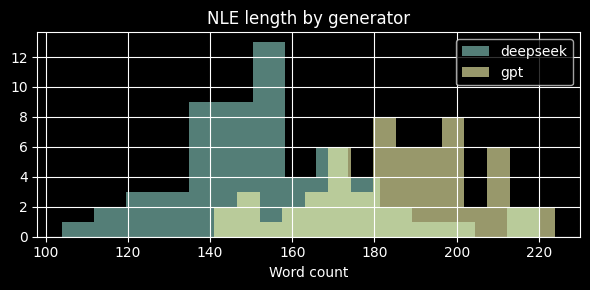


=== Sample NLEs (first instance) ===

[deepseek]
- **Key drivers**: The prediction (172.45 kWh) is **below the baseline (177.37 kWh)**. This is mostly due to **lag_6** (energy use 6 weeks ago being low), dragging the forecast down, and **lag_1** (last week's high usage) slightly reducing it further.  
- **Offsetting factors**: **lag_2** (higher usage 2 weeks ago) and **lag_7** (low usage 7 weeks ago) pushed the prediction upward, balancing some of the downward pressure.  
- **Seasonality**: The model detected a small boost from the **weekofyear (43 = late October)**, aligning with typical energy patterns (e.g., cooler weather).  
- **Holidays**: No public holidays this week – minimal impact.  
- **Confidence**: The model’s **average error (MAE) is ~20.5 kWh**, meaning the true value is likely between ~152–192 kWh. The **R² (0.69)** suggests it explains ~69% of energy use variation – moderate reliability.  
- **Risk**: If recent weeks (lag_1/lag_6) are unusually volatile (e.g., outlier

In [7]:
import matplotlib.pyplot as plt

cache = utils.load_nle_cache()
valid = cache[cache['Explanation'].notna() & (cache['Explanation'] != '')].copy()
valid['nle_words'] = valid['Explanation'].str.split().str.len()
valid['error_bucket'] = valid['PctError'].apply(utils.pct_error_to_bucket)

print('=== NLE Statistics by Generator ===')
print(valid.groupby('generator')['nle_words'].agg(['mean', 'min', 'max']).round(1))

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for gen, grp in valid.groupby('generator'):
    grp['nle_words'].hist(ax=ax, alpha=0.6, label=gen, bins=15)
ax.set_xlabel('Word count')
ax.set_title('NLE length by generator')
ax.legend()
plt.tight_layout()
plt.savefig(utils.RESULTS_DIR / 'nle_length_stats.png', dpi=150)
plt.show()

print('\n=== Sample NLEs (first instance) ===')
for gen, grp in valid.groupby('generator'):
    print(f'\n[{gen}]')
    print(grp.iloc[0]['Explanation'])

In [8]:
cache = utils.load_nle_cache()
print('=== NLE Generation Complete ===')
print(f'GPT cache : {CACHE_GPT}')
print(f'DS cache  : {CACHE_DS}')
print(f'Total rows: {len(cache)} (expect 120 = 60 × 2 generators)')
print()
print('Next steps:')
print('  E1: Code/new_experiments/E1_closeness_task.ipynb')
print('  E3: Code/new_experiments/E3_counterfactual_simulatability.ipynb')
print('  E4: Code/new_experiments/E4_mental_model_transfer.ipynb')
print('  E5: Code/new_experiments/E5_placebic_nle_control.ipynb')

=== NLE Generation Complete ===
GPT cache : /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/nle/nle_cache_gpt.csv
DS cache  : /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/nle/nle_cache_deepseek.csv
Total rows: 120 (expect 120 = 60 × 2 generators)

Next steps:
  E1: Code/new_experiments/E1_closeness_task.ipynb
  E3: Code/new_experiments/E3_counterfactual_simulatability.ipynb
  E4: Code/new_experiments/E4_mental_model_transfer.ipynb
  E5: Code/new_experiments/E5_placebic_nle_control.ipynb
